In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
data_df = pd.read_json("/kaggle/input/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json", lines=True)

In [4]:
data_df.sample(5)

,article_link,headline,is_sarcastic
5477,https://www.huffingtonpost.com/entry/heres-why...,here's why the internet is convinced kylie jen...,0
525,https://www.theonion.com/swiss-unable-to-maint...,swiss unable to maintain neutrality toward del...,1
26317,https://www.theonion.com/milkshake-almost-ruin...,milkshake almost ruined by breakup,1
9257,https://politics.theonion.com/you-are-not-your...,"'you are not your job,' obama reminds himself ...",1
5490,https://www.huffingtonpost.com/entry/morgan-sp...,morgan spurlock admits history of sexual misco...,0


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26709 entries, 0 to 26708
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_link  26709 non-null  object
 1   headline      26709 non-null  object
 2   is_sarcastic  26709 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 626.1+ KB


In [6]:
data_df.dropna(inplace=True)
data_df.drop_duplicates(inplace=True)

In [7]:
data_df.drop(['article_link'], axis=1, inplace=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(np.array(data_df['headline']), np.array(data_df['is_sarcastic']), test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

In [9]:
X_val.shape

(4006,)

In [10]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

2025-04-14 13:48:35.380616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744638515.579590      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744638515.637657      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [11]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = [tokenizer(x,
                           max_length=100,
                           truncation=True,
                           padding='max_length',
                           return_tensors='pt').to(device)
                  for x in X
                 ]
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

In [12]:
train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)
val_dataset = dataset(X_val, y_val)

In [13]:
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

In [14]:
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, shuffle=True, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(val_dataset, shuffle=True, batch_size=BATCH_SIZE)

In [15]:
class my_model(nn.Module):
    def __init__(self, bert):
        super(my_model, self).__init__()

        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        pooled_output = self.bert(input_ids, attention_mask, return_dict=False)[0][:,0]
        output = self.linear1(pooled_output)
        output = self.dropout(output)
        output = self.linear2(output)
        output = self.dropout(output)
        output = self.sigmoid(output)

        return output
        

In [16]:
for param in bert_model.parameters():
    param.requires_grad = False
model = my_model(bert_model).to(device)

In [17]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr=LR)

In [18]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_loss_train = 0
    total_acc_train = 0
    total_loss_val = 0
    total_acc_val = 0
    for data in train_dataloader:
        optimizer.zero_grad()
        inputs, labels = data

        preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)

        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
        total_acc_train += (preds.round() == labels).sum().item()

    with torch.no_grad():
        
        for data in val_dataloader:
            inputs, labels = data
    
            preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    
            loss = criterion(preds, labels)
    
            total_loss_val += loss.item()
            total_acc_val += (preds.round() == labels).sum().item()


    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() *100, 4))
    total_loss_val_plot.append(round(total_loss_val/1000,4))
    total_acc_val_plot.append(round(total_acc_val/val_dataset.__len__() *100, 4))

    print(f"epoch:{epoch}, train_loss:{round(total_loss_train/1000,4)}, train_acc{round(total_acc_train/train_dataset.__len__() *100, 4)}")
    print(f"epoch:{epoch}, val_loss:{round(total_loss_val/1000,4)}, val_acc{round(total_acc_val/val_dataset.__len__() *100, 4)}")
    


epoch:0, train_loss:0.2944, train_acc73.9021
epoch:0, val_loss:0.0596, val_acc75.6365
epoch:1, train_loss:0.2594, train_acc77.5555
epoch:1, val_loss:0.0555, val_acc77.7833
epoch:2, train_loss:0.2526, train_acc77.946
epoch:2, val_loss:0.0548, val_acc77.3839
epoch:3, train_loss:0.2485, train_acc77.9995
epoch:3, val_loss:0.0545, val_acc78.3824
epoch:4, train_loss:0.2452, train_acc78.0476
epoch:4, val_loss:0.0539, val_acc77.8832
epoch:5, train_loss:0.2423, train_acc78.4541
epoch:5, val_loss:0.0542, val_acc77.9331
epoch:6, train_loss:0.2401, train_acc78.9837
epoch:6, val_loss:0.0521, val_acc78.1078
epoch:7, train_loss:0.2376, train_acc78.9035
epoch:7, val_loss:0.0533, val_acc79.1563
epoch:8, train_loss:0.2361, train_acc78.9088
epoch:8, val_loss:0.0514, val_acc79.1563
epoch:9, train_loss:0.2364, train_acc79.2083
epoch:9, val_loss:0.0534, val_acc78.4324


In [19]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_dataloader:
            inputs, labels = data
    
            preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    
            loss = criterion(preds, labels)
    
            total_loss_test += loss.item()
            total_acc_test += (preds.round() == labels).sum().item()

print(f"test_loss:{round(total_loss_test/1000,4)}, train_acc{round(total_acc_test/test_dataset.__len__() *100, 4)}")
  

test_loss:0.0523, train_acc78.0634


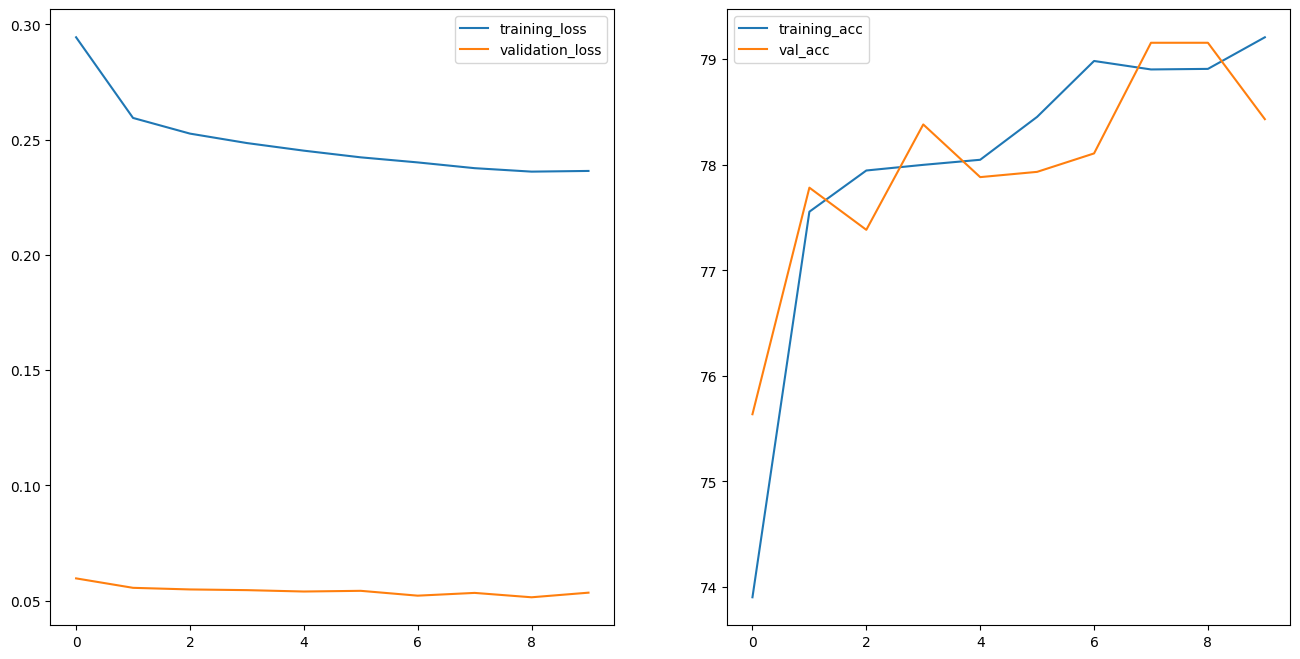

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,8))
axs[0].plot(total_loss_train_plot, label='training_loss')
axs[0].plot(total_loss_val_plot, label='validation_loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='training_acc')
axs[1].plot(total_acc_val_plot, label='val_acc')
axs[1].legend()